Journée Data Science

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
train_df = pd.read_csv('../data/farms_train.csv')
test_df = pd.read_csv('../data/farms_test.csv')
X_complet = train_df.drop('DIFF', axis=1)
y = train_df['DIFF']

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm_rigide = SVC(kernel='rbf', C=1000, random_state=42)
svm_souple = SVC(kernel='rbf', C=0.1, random_state=42)

# 4. VALIDATION CROISÉE : on récupère les scores de décision au lieu des classes brutes
# cv=5 signifie que les données sont coupées en 5. L'algorithme tourne 5 fois.
print("Calcul des scores en validation croisée (cv=5)...")
scores_rigide = cross_val_predict(svm_rigide, X_scaled, y, cv=5, method='decision_function')
scores_souple = cross_val_predict(svm_souple, X_scaled, y, cv=5, method='decision_function')

# 5. Calcul des vrais AUC basés sur la validation croisée
auc_rigide = roc_auc_score(y, scores_rigide)
auc_souple = roc_auc_score(y, scores_souple)

# 6. Préparation des points de la courbe ROC
fpr_rigide, tpr_rigide, _ = roc_curve(y, scores_rigide)
fpr_souple, tpr_souple, _ = roc_curve(y, scores_souple)



Calcul des scores en validation croisée (cv=5)...


AUC (Validation Croisée) du SVM Rigide (C=1000) : 0.775
AUC (Validation Croisée) du SVM Souple (C=0.1)  : 0.886


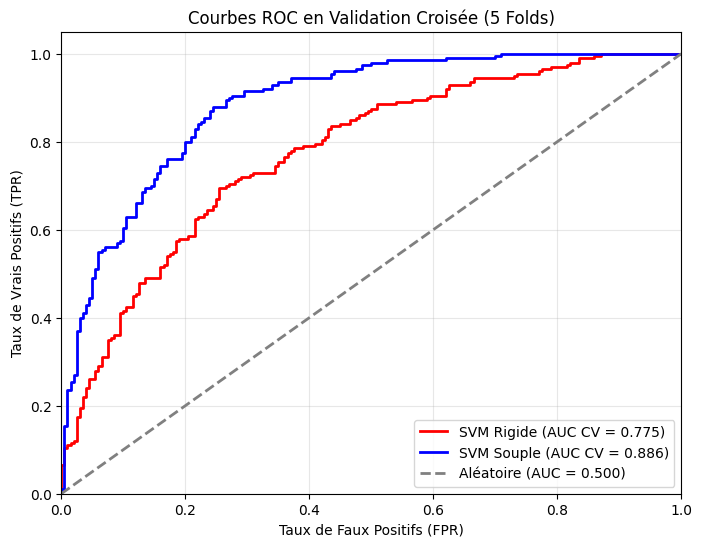

In [22]:
# 7. Affichage des résultats
print(f"AUC (Validation Croisée) du SVM Rigide (C=1000) : {auc_rigide:.3f}")
print(f"AUC (Validation Croisée) du SVM Souple (C=0.1)  : {auc_souple:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_rigide, tpr_rigide, color='red', lw=2, 
         label=f'SVM Rigide (AUC CV = {auc_rigide:.3f})')
plt.plot(fpr_souple, tpr_souple, color='blue', lw=2, 
         label=f'SVM Souple (AUC CV = {auc_souple:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Aléatoire (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbes ROC en Validation Croisée (5 Folds)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Varations des Parametres

In [ ]:
combinaisons_a_supprimer = [
    []
]

# 3. Définition de la grille d'hyperparamètres
c_values = np.logspace(-3, 3, 50)
param_grid = [
    {'kernel': ['linear', 'rbf'], 'C': c_values},
    {'kernel': ['poly'], 'degree': [2, 3], 'C': c_values},
    {'kernel': [cosine_similarity], 'C': c_values}
]

metrics = ['roc_auc', 'accuracy', 'f1']
tous_les_resultats = []

print(f"Lancement de l'exploration globale...")
print(f"Nombre de combinaisons de variables : {len(combinaisons_a_supprimer)}")
print("-" * 50)

# 4. Boucle sur chaque combinaison de variables
for cols_to_drop in combinaisons_a_supprimer:
    nom_combinaison = "Aucune" if not cols_to_drop else ", ".join(cols_to_drop)
    print(f"Test en cours - Variables supprimées : {nom_combinaison}...")
    
    # Préparation du sous-ensemble de données
    X_subset = X_complet.drop(columns=cols_to_drop)
    
    # Normalisation spécifique à ce sous-ensemble
    scaler = StandardScaler()
    X_subset_scaled = scaler.fit_transform(X_subset)
    
    # Configuration et lancement du GridSearchCV
    grid = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring=metrics,
        refit='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_subset_scaled, y)
    
    # Récupération des résultats
    results_df = pd.DataFrame(grid.cv_results_)
    
    # Ajout d'une colonne pour identifier quelles variables ont été enlevées
    results_df['Variables_Supprimees'] = nom_combinaison
    
    # Stockage pour la compilation finale
    tous_les_resultats.append(results_df)

# 5. Compilation et nettoyage du classement final
# On fusionne tous les tableaux générés par la boucle
master_results_df = pd.concat(tous_les_resultats, ignore_index=True)

# Sélection des colonnes pertinentes
colonnes_utiles = [
    'Variables_Supprimees', 'param_kernel', 'param_C', 'param_degree',
    'mean_test_roc_auc', 'mean_test_accuracy', 'mean_test_f1'
]
tableau_final = master_results_df[colonnes_utiles].copy()

# Renommage
tableau_final.columns = [
    'Variables Supprimées', 'Noyau', 'C', 'Degré (si poly)', 
    'AUC (Moyen)', 'Accuracy (Moyenne)', 'F1 (Moyen)'
]

# Nettoyage de l'affichage (Cosinus, Degré et Arrondis)
tableau_final['Noyau'] = tableau_final['Noyau'].astype(str).apply(
    lambda x: 'cosinus' if 'cosine_similarity' in x else x
)
tableau_final['Degré (si poly)'] = tableau_final['Degré (si poly)'].fillna('-')
tableau_final['C'] = tableau_final['C'].round(4)

# Recalcul du classement global basé sur l'AUC (car chaque itération avait son propre classement 1 à N)
tableau_final['Rang Global AUC'] = tableau_final['AUC (Moyen)'].rank(method='min', ascending=False).astype(int)

# Tri du meilleur (1) au moins bon
tableau_final = tableau_final.sort_values(by='Rang Global AUC')

# 6. Affichage des résultats
print("\n" + "="*80)
print("--- TOP 20 DES MEILLEURES COMBINAISONS GLOBALES (Variables + Hyperparamètres) ---")
print("="*80)
# On réorganise l'ordre des colonnes pour mettre le rang en premier
cols = ['Rang Global AUC'] + [c for c in tableau_final.columns if c != 'Rang Global AUC']
print(tableau_final[cols].head(50).to_string(index=False))

# Exportation recommandée pour une analyse confortable dans LibreOffice Calc
tableau_final[cols].to_csv('classement_complet_variables_svm.csv', index=False)
print("\n-> Le classement complet a été sauvegardé dans 'classement_complet_variables_svm.csv'.")

Lancement de l'exploration globale...
Nombre de combinaisons de variables : 8
--------------------------------------------------
Test en cours - Variables supprimées : Aucune...
Test en cours - Variables supprimées : AGE, R22, R8...
Test en cours - Variables supprimées : AGE, R22...
Test en cours - Variables supprimées : R22, R8...
Test en cours - Variables supprimées : AGE, R8...
Test en cours - Variables supprimées : AGE...
Test en cours - Variables supprimées : R8...
Test en cours - Variables supprimées : R22...

--- TOP 20 DES MEILLEURES COMBINAISONS GLOBALES (Variables + Hyperparamètres) ---
 Rang Global AUC Variables Supprimées  Noyau         C Degré (si poly)  AUC (Moyen)  Accuracy (Moyenne)  F1 (Moyen)
               1         AGE, R22, R8 linear    8.2864               -     0.893875              0.8250    0.832166
               2                  AGE linear    6.2506               -     0.893750              0.8375    0.843035
               2         AGE, R22, R8 linear   1